<a href="https://colab.research.google.com/github/IshikaGeed/HackOweek/blob/main/HackOWeek2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!ls


household_power_consumption.txt  sample_data


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
df = pd.read_csv(
    "/content/household_power_consumption.txt",
    sep=";",
    low_memory=False
)

print(df.head())
print(df.shape)


         Date      Time Global_active_power Global_reactive_power  Voltage  \
0  16/12/2006  17:24:00               4.216                 0.418  234.840   
1  16/12/2006  17:25:00               5.360                 0.436  233.630   
2  16/12/2006  17:26:00               5.374                 0.498  233.290   
3  16/12/2006  17:27:00               5.388                 0.502  233.740   
4  16/12/2006  17:28:00               3.666                 0.528  235.680   

  Global_intensity Sub_metering_1 Sub_metering_2  Sub_metering_3  
0           18.400          0.000          1.000            17.0  
1           23.000          0.000          1.000            16.0  
2           23.000          0.000          2.000            17.0  
3           23.000          0.000          1.000            17.0  
4           15.800          0.000          1.000            17.0  
(2075259, 9)


In [ ]:
df["DateTime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    format="%d/%m/%Y %H:%M:%S",
    errors="coerce"
)

df = df.set_index("DateTime")
df = df.drop(columns=["Date", "Time"])

print(df.head())


                    Global_active_power Global_reactive_power  Voltage  \
DateTime                                                                 
2006-12-16 17:24:00               4.216                 0.418  234.840   
2006-12-16 17:25:00               5.360                 0.436  233.630   
2006-12-16 17:26:00               5.374                 0.498  233.290   
2006-12-16 17:27:00               5.388                 0.502  233.740   
2006-12-16 17:28:00               3.666                 0.528  235.680   

                    Global_intensity Sub_metering_1 Sub_metering_2  \
DateTime                                                             
2006-12-16 17:24:00           18.400          0.000          1.000   
2006-12-16 17:25:00           23.000          0.000          1.000   
2006-12-16 17:26:00           23.000          0.000          2.000   
2006-12-16 17:27:00           23.000          0.000          1.000   
2006-12-16 17:28:00           15.800          0.000          

In [ ]:
df["Global_active_power"] = pd.to_numeric(
    df["Global_active_power"],
    errors="coerce"
)

print("Missing values:", df["Global_active_power"].isna().sum())


Missing values: 25979


In [ ]:
df = df.dropna(subset=["Global_active_power"])


In [ ]:
hourly_power = df["Global_active_power"].resample("H").sum()

print(hourly_power.head())


/tmp/ipython-input-4208993574.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_power = df["Global_active_power"].resample("H").sum()


DateTime
2006-12-16 17:00:00    152.024
2006-12-16 18:00:00    217.932
2006-12-16 19:00:00    204.014
2006-12-16 20:00:00    196.114
2006-12-16 21:00:00    183.388
Freq: h, Name: Global_active_power, dtype: float64


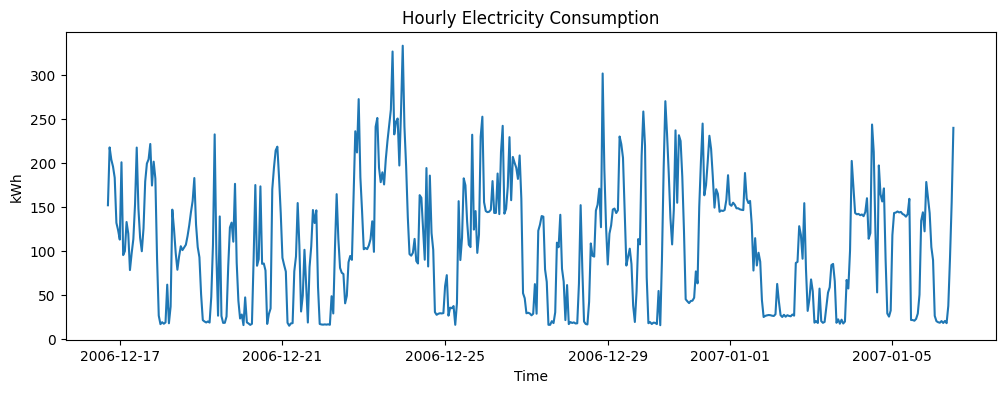

In [ ]:
plt.figure(figsize=(12,4))
plt.plot(hourly_power[:500])
plt.title("Hourly Electricity Consumption")
plt.xlabel("Time")
plt.ylabel("kWh")
plt.show()


In [ ]:
hourly_power.to_csv("hourly_energy_consumption.csv")
print("hourly_energy_consumption.csv saved")


hourly_energy_consumption.csv saved


In [ ]:
!pip install statsmodels


In [ ]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(hourly_power, order=(1,1,1))
model_fit = model.fit()

print(model_fit.summary())


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


                                SARIMAX Results                                
Dep. Variable:     Global_active_power   No. Observations:                34589
Model:                  ARIMA(1, 1, 1)   Log Likelihood             -174249.776
Date:                 Thu, 22 Jan 2026   AIC                         348505.551
Time:                         05:50:48   BIC                         348530.905
Sample:                     12-16-2006   HQIC                        348513.632
                          - 11-26-2010                                         
Covariance Type:                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6827      0.003    214.968      0.000       0.677       0.689
ma.L1         -0.9952      0.001  -1693.497      0.000      -0.996      -0.994
sigma2      1391.0659      6.580    211.414 

In [ ]:
forecast = model_fit.get_forecast(steps=1)

predicted_value = forecast.predicted_mean.iloc[0]
confidence_interval = forecast.conf_int().iloc[0]

print("Next-hour prediction (kWh):", predicted_value)
print("Confidence Interval:")
print(confidence_interval)


Next-hour prediction (kWh): 24.018003556262265
Confidence Interval:
lower Global_active_power   -49.082766
upper Global_active_power    97.118773
Name: 2010-11-26 22:00:00, dtype: float64


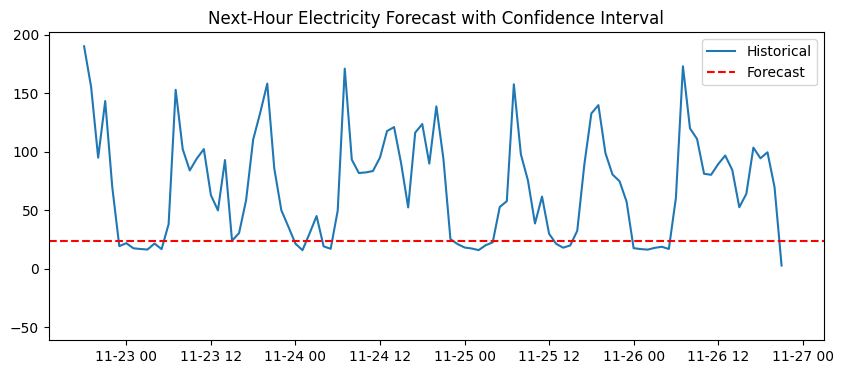

In [ ]:
ci = forecast.conf_int()

plt.figure(figsize=(10,4))
plt.plot(hourly_power[-100:], label="Historical")
plt.axhline(predicted_value, color="red", linestyle="--", label="Forecast")
plt.fill_between(ci.index, ci.iloc[:,0], ci.iloc[:,1], alpha=0.3)
plt.legend()
plt.title("Next-Hour Electricity Forecast with Confidence Interval")
plt.show()
